#### Week 7 - Supervised Learning: creating training data

Turn an **unlabeled** pile of images into a **labeled classifier** - by naming the
typologies you found last week (Week 6). Same case, the next step.

Flow: pick a perspective -> SOM (recap Week 6) -> **name the typologies** -> train a
classifier -> read the confusion matrix -> predict + map -> export your labels.

##### > Point this at your own data

`DATA_ROOT` (next cell) is one **case**. Each subfolder inside it is a **perspective**
(a scale / view) full of images. The demo case `data_KSO` (Detroit) has three:
`downloaded_images`, `streetview_images`, `satellite_images`.

To use **your own** data: put your images in one or more subfolders inside a case
folder, then set `DATA_ROOT` to that folder. Everything else runs the same.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [25]:
# --- one-time installs (Colab); does nothing if already present ---
import importlib.util, subprocess, sys
for pkg, pip_name in [('open_clip', 'open_clip_torch'), ('ipywidgets', 'ipywidgets'),
                      ('minisom', 'minisom')]:
    if importlib.util.find_spec(pkg) is None:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pip_name])

import csv, re, math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import ipywidgets as widgets
from IPython.display import display
%matplotlib inline

# ============ POINT THIS AT YOUR OWN DATA ============
DATA_ROOT = 'Colab Notebooks/ML_for_Architects/'      # a case folder; each subfolder = one perspective
# ====================================================

MAX_IMAGES = 400            # cap per perspective (speed / memory safety belt)
SEED = 46
IMG_EXTS = {'.jpg', '.jpeg', '.png'}

root = Path(DATA_ROOT)
assert root.exists(), f'Folder not found: {root.resolve()} -- edit DATA_ROOT above.'

def list_images(folder):
    return sorted(p for p in Path(folder).glob('*')
                  if p.is_file() and p.suffix.lower() in IMG_EXTS)

def parse_latlon(p):
    # streetview / satellite files are named 'lat_lon.jpg' -> (lat, lon), else None
    m = re.match(r'^(-?\d+\.\d+)_(-?\d+\.\d+)$', Path(p).stem)
    return (float(m.group(1)), float(m.group(2))) if m else None

# perspectives = subfolders that actually contain images
PERSPECTIVES = [d.name for d in sorted(root.iterdir()) if d.is_dir() and list_images(d)]
assert PERSPECTIVES, f'No image subfolders found under {root}.'
print('Case:', root.name, '| perspectives:', PERSPECTIVES)

Case: downtown_jax | perspectives: ['aerial', 'facade']


#### 1. Pick - a perspective (scale) of the case

In [16]:
# PICK: which perspective to work on. The default just works; change it and re-run
# the cells below to switch scales.
perspective = widgets.Dropdown(options=PERSPECTIVES, value=PERSPECTIVES[0],
                               description='Perspective:')
display(perspective)

Dropdown(description='Perspective:', options=('aerial', 'facade'), value='aerial')

In [17]:
# Load the chosen perspective's images and CLIP-embed them (cached per perspective).
try:
    _model
except NameError:
    import torch, open_clip
    _device = 'cuda' if torch.cuda.is_available() else 'cpu'
    _model, _, _preprocess = open_clip.create_model_and_transforms(
        'ViT-B-32', pretrained='laion2b_s34b_b79k')
    _model = _model.to(_device).eval()
    print('CLIP loaded on', _device)

_cache = globals().get('_cache', {})
def embed_perspective(name):
    if name in _cache:
        return _cache[name]
    import torch
    fs = list_images(root / name)[:MAX_IMAGES]
    feats, keep = [], []
    for i in range(0, len(fs), 64):
        ims, ok = [], []
        for p in fs[i:i + 64]:
            try:
                ims.append(_preprocess(Image.open(p).convert('RGB'))); ok.append(p)
            except Exception:
                pass
        if not ims:
            continue
        with torch.no_grad():
            f = _model.encode_image(torch.stack(ims).to(_device))
            f = f / f.norm(dim=-1, keepdim=True)
        feats.append(f.cpu().numpy()); keep += ok
    Xe = np.concatenate(feats).astype(np.float32)
    _cache[name] = (keep, Xe)
    return keep, Xe

files, X = embed_perspective(perspective.value)
ll = [parse_latlon(p) for p in files]
print(f'{perspective.value}: {len(files)} images embedded -> {X.shape[1]}-d features')

facade: 400 images embedded -> 512-d features


#### 2. Recap Week 6 - Self-Organizing Map (SOM), grouped into typologies

In [18]:
# TUNE: how many typologies (classes) to end up with.
k = widgets.IntSlider(value=6, min=2, max=12, step=1, description='typologies k:')
display(k)

IntSlider(value=6, description='typologies k:', max=12, min=2)

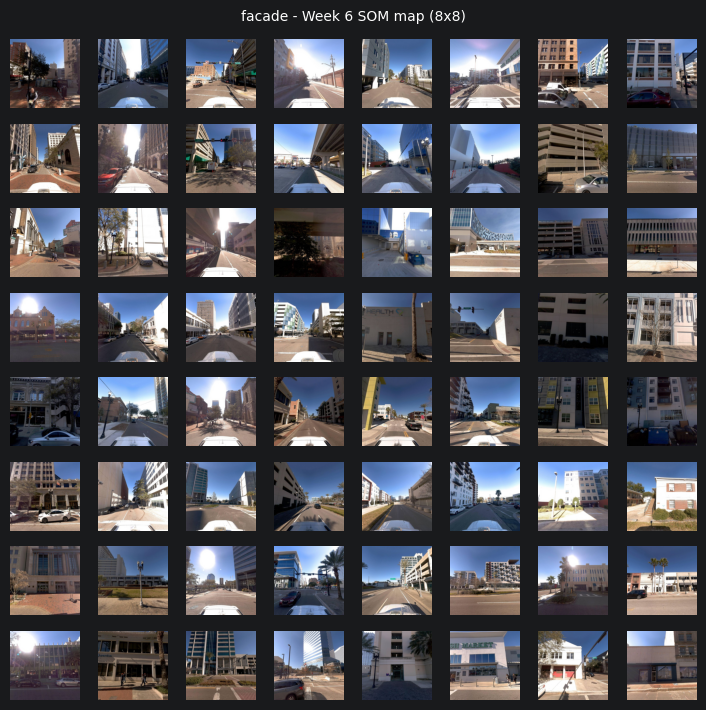

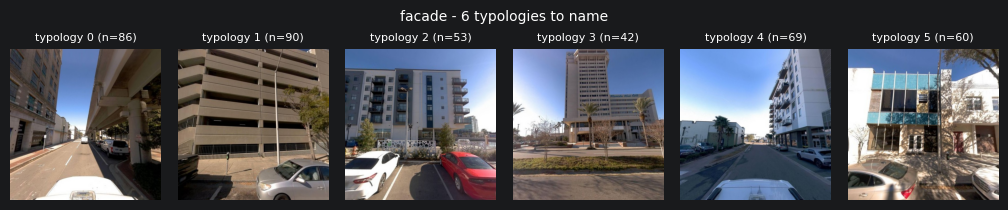

In [19]:
# Recap Week 6 with a Self-Organizing Map, then bundle its cells into k typologies.
from minisom import MiniSom
from sklearn.cluster import KMeans

# 1) Train a SOM (same method as Week 6): organize the images on an m x m grid.
m = max(3, min(8, int(round((len(X) / 6) ** 0.5))))
som = MiniSom(m, m, X.shape[1], sigma=1.0, learning_rate=0.5,
              activation_distance='cosine', random_seed=SEED)
som.random_weights_init(X)
som.train_random(X, 1500)
win = np.array([som.winner(x) for x in X])          # winning cell (i, j) per image

# show the SOM typology map: the representative image in each cell
Wg = som.get_weights()
def _node_rep(i, j):
    mem = np.where((win[:, 0] == i) & (win[:, 1] == j))[0]
    if len(mem) == 0:
        return None
    return mem[(((X[mem] - Wg[i, j]) ** 2).sum(1)).argmin()]
plt.figure(figsize=(m * 0.9, m * 0.9))
for i in range(m):
    for j in range(m):
        ax = plt.subplot(m, m, i * m + j + 1); ax.axis('off')
        r = _node_rep(i, j)
        if r is not None:
            ax.imshow(Image.open(files[r]).convert('RGB'))
plt.suptitle(f'{perspective.value} - Week 6 SOM map ({m}x{m})', fontsize=10)
plt.tight_layout(); plt.show()

# 2) Coarsen: group the SOM's cells into k typologies (KMeans on the cell vectors),
#    so neighbouring cells on the map bundle into the few classes you will name.
Wflat = Wg.reshape(m * m, X.shape[1])
node_group = np.array{[

]}


node_group = KMeans(k.value, n_init=10, random_state=SEED).fit_predict(Wflat)
clust = node_group[win[:, 0] * m + win[:, 1]]        # each image -> its typology
present = sorted(set(clust.tolist()))
remap = {old: new for new, old in enumerate(present)}
clust = np.array([remap[c] for c in clust])
K = len(present)                                     # typologies actually populated
if K < k.value:
    print(f'note: asked for {k.value} typologies, {K} were populated.')

# show one representative image per typology (the classes you will name next)
gmean = np.stack([X[clust == c].mean(0) for c in range(K)])
def rep_index(c):
    idx = np.where(clust == c)[0]
    return idx[(((X[idx] - gmean[c]) ** 2).sum(1)).argmin()]
cols = min(K, 6); rows = math.ceil(K / cols)
plt.figure(figsize=(1.7 * cols, 2.1 * rows))
for c in range(K):
    plt.subplot(rows, cols, c + 1)
    plt.imshow(Image.open(files[rep_index(c)]).convert('RGB'))
    plt.title(f'typology {c} (n={int((clust == c).sum())})', fontsize=8)
    plt.axis('off')
plt.suptitle(f'{perspective.value} - {K} typologies to name', fontsize=10)
plt.tight_layout(); plt.show()

#### 3. Author - name each typology (these become your labels)

In [20]:
# AUTHOR: give each typology a name -> that name labels every image in it.
# Pre-filled with 'type_i' so it runs even if you skip this, but rename them to
# meaningful classes (e.g. 'brick_rowhouse', 'vacant_lot', 'glass_tower').
name_boxes = [widgets.Text(value=f'type_{c}', description=f'typology {c}:')
              for c in range(K)]
display(widgets.VBox(name_boxes))

In [21]:
# Turn the typology names into a label for every image (blank name -> type_i).
names = [(b.value.strip() or f'type_{i}') for i, b in enumerate(name_boxes)]
y = np.array([names[c] for c in clust])

classes, counts = np.unique(y, return_counts=True)
print('Your classes:')
for cl, ct in zip(classes, counts):
    print(f'  {cl:22s} {ct}')
assert len(classes) >= 2, 'Need at least 2 different class names to train.'
tiny = [cl for cl, ct in zip(classes, counts) if ct < 5]
if tiny:
    print('\n[heads-up] very small classes (add images or merge):', tiny)

Your classes:
  type_0                 86
  type_1                 90
  type_2                 53
  type_3                 42
  type_4                 69
  type_5                 60


#### 4. Tune + train the classifier

test accuracy: 0.80


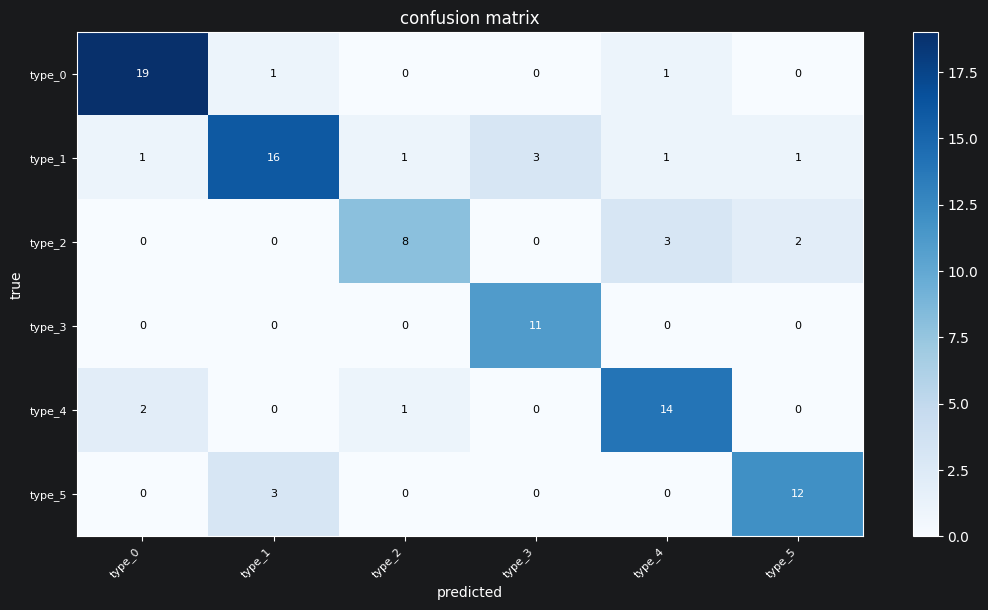

In [26]:
# TUNE two knobs, then train on your labels and read an honest (held-out) score.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

USE_NET = True          # False = simple linear model; True = small neural net
TEST_FRACTION = 0.25     # share held out to test honesty

_, cnts = np.unique(y, return_counts=True)
strat = y if cnts.min() >= 2 else None      # safety belt for tiny classes
Xtr, Xte, ytr, yte, itr, ite = train_test_split(
    X, y, np.arange(len(y)), test_size=TEST_FRACTION, random_state=SEED, stratify=strat)
clf = (MLPClassifier(hidden_layer_sizes=(128,128,), max_iter=500, random_state=SEED)
       if USE_NET else LogisticRegression(max_iter=2000))
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)
print(f'test accuracy: {accuracy_score(yte, pred):.2f}')

labs = sorted(set(y))
cm = confusion_matrix(yte, pred, labels=labs)
# rectangular figure; annotate every cell with its count
plt.figure(figsize=(1.3 * len(labs) + 3, 0.7 * len(labs) + 2))
plt.imshow(cm, cmap='Blues', aspect='auto')
plt.xticks(range(len(labs)), labs, rotation=45, ha='right', fontsize=8)
plt.yticks(range(len(labs)), labs, fontsize=8)
thr = cm.max() / 2 if cm.max() else 0
for i in range(len(labs)):
    for j in range(len(labs)):
        plt.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=8,
                 color='white' if cm[i, j] > thr else 'black')
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('confusion matrix')
plt.colorbar(); plt.tight_layout(); plt.show()

#### 5. Predict + map

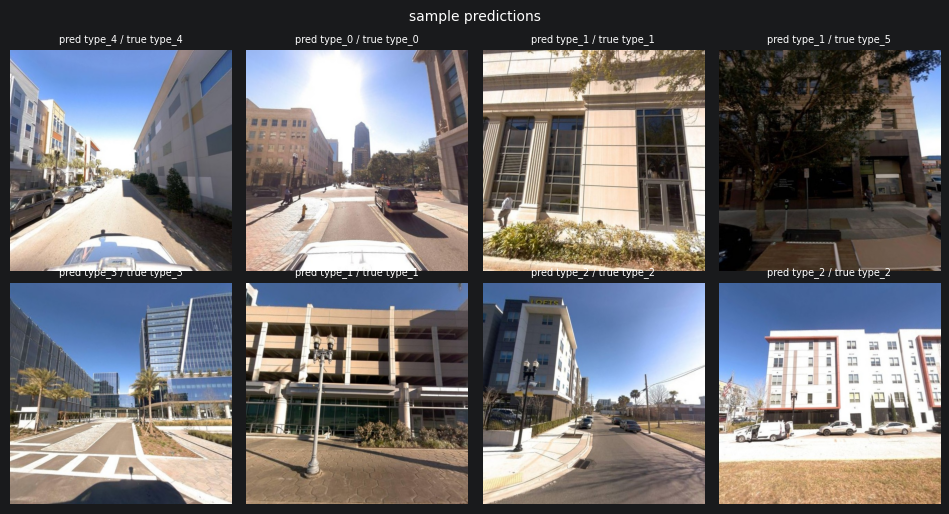

(no lat/lon in these filenames -- map skipped for this perspective)


In [27]:
# A few held-out predictions (image: predicted vs true).
show = ite[:8]
cols = 4; rows = math.ceil(len(show) / cols)
plt.figure(figsize=(2.4 * cols, 2.6 * rows))
for j, gi in enumerate(show):
    plt.subplot(rows, cols, j + 1)
    plt.imshow(Image.open(files[gi]).convert('RGB'))
    plt.title(f'pred {clf.predict(X[gi:gi + 1])[0]} / true {y[gi]}', fontsize=7)
    plt.axis('off')
plt.suptitle('sample predictions', fontsize=10); plt.tight_layout(); plt.show()

# If this perspective is geotagged (lat_lon filenames), map the predicted classes.
if any(ll):
    allpred = clf.predict(X)
    lats = np.array([c[0] if c else np.nan for c in ll])
    lons = np.array([c[1] if c else np.nan for c in ll])
    plt.figure(figsize=(6, 5))
    for cl in sorted(set(allpred)):
        sel = (allpred == cl) & ~np.isnan(lats)
        plt.scatter(lons[sel], lats[sel], s=14, label=cl)
    plt.legend(fontsize=7, markerscale=1.5)
    plt.xlabel('lon'); plt.ylabel('lat')
    plt.title(f'{perspective.value} - predicted classes on the map'); plt.show()
else:
    print('(no lat/lon in these filenames -- map skipped for this perspective)')

#### 6. Export your labeled dataset

In [ ]:
# Save image -> label (the training data you just built). This feeds Week 11.
out = root / perspective.value / 'labels.csv'
with open(out, 'w', newline='', encoding='utf-8') as f:
    w = csv.writer(f)
    w.writerow(['filename', 'typology', 'label', 'lat', 'lon'])
    for p, c, lab, geo in zip(files, clust, y, ll):
        la, lo = geo if geo else ('', '')
        w.writerow([Path(p).name, int(c), lab, la, lo])
print('saved', out, f'({len(files)} rows)')

You just **created training data** from the SOM typologies and trained a classifier on
**your own** categories. The same images carry into **Week 11 (computer vision)** - swap
`DATA_ROOT` to your scrape and the whole notebook runs on your data.